# Exploratory Data Analysis

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# load data
df = pd.read_csv('../data/clean/5_beforward_clean_data.csv')
df

,make,model,model_code,year,car_age,engine_cc,engine_code,fuel,transmission_type,drive,...,doors,price_usd,total_price_usd,shipping_cost,location,destination_port,accessories,vehicle_id,ref_no,vehicle_url
0,JEEP,WRANGLER UNLIMITED SAHARA,ABA-JL36L,2019,7,"3,600.00",G,Petrol,Automatic,4WD,...,5.00,"16,980.00","19,896.00","2,916.00",Yokohama,Mombasa,[''],15018558,CD066265,/jeep/wrangler/cd066265/id/15018558/?mfg_year_...
1,HONDA,ACCORD,NaN,2019,7,"1,500.00",NaN,Petrol,Automatic,2WD,...,4.00,"27,740.00","29,731.00","1,991.00",Thailand,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",14864798,CC842281,/honda/accord/cc842281/id/14864798/?mfg_year_f...
2,HONDA,CITY,NaN,2024,2,"1,000.00",NaN,Petrol,Automatic,2WD,...,4.00,"17,190.00","18,416.00","1,226.00",Thailand,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",14864891,CC842374,/honda/city/cc842374/id/14864891/?mfg_year_fro...
3,HONDA,BR-V,NaN,2024,2,"1,500.00",NaN,Petrol,Automatic,2WD,...,5.00,"22,080.00","24,107.00","2,027.00",Thailand,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",14864903,CC842386,/honda/br-v/cc842386/id/14864903/?mfg_year_fro...
4,HONDA,CR-V,NaN,2023,3,"1,500.00",NaN,Petrol,Automatic,4WD,...,5.00,"40,390.00","42,560.00","2,170.00",Thailand,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",14864910,CC842393,/honda/cr-v/cc842393/id/14864910/?mfg_year_fro...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24770,ISUZU,D-MAX 3.0 SX DOUBLE CAB,SX,2026,0,"3,000.00",NaN,Diesel,Automatic,4WD,...,4.00,"41,260.00","46,045.00","4,785.00",Australia,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",15172794,CD219642,/isuzu/d-max/cd219642/id/15172794/?mfg_year_fr...
24771,ISUZU,D-MAX 3.0 LS-U+ DOUBLE CAB,LS-U,2026,0,"3,000.00",NaN,Diesel,Automatic,4WD,...,4.00,"50,090.00","54,775.00","4,685.00",Australia,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",15172792,CD219641,/isuzu/d-max/cd219641/id/15172792/?mfg_year_fr...
24772,ISUZU,D-MAX 3.0 LS-U+ DOUBLE CAB,LS-U,2026,0,"3,000.00",NaN,Diesel,Automatic,4WD,...,4.00,"54,520.00","59,205.00","4,685.00",Australia,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",15172791,CD219640,/isuzu/d-max/cd219640/id/15172791/?mfg_year_fr...
24773,ISUZU,D-MAX 3.0 LS-U+ DOUBLE CAB,LS-U,2025,1,"3,000.00",NaN,Diesel,Automatic,4WD,...,4.00,"51,910.00","56,595.00","4,685.00",Australia,Mombasa,"['Power Steering', 'A/C', 'Airbag', 'Leather S...",15172790,CD219639,/isuzu/d-max/cd219639/id/15172790/?mfg_year_fr...


In [4]:
# Basic inpections
print("Basic inspection results\n")
print(f"Shape : {df.shape}\n")
print(f"Columns: {list(df.columns)}\n")

print("First 5 rows")
print(df.head())

print("\nSummary statistic")
print(df.describe().round(2))

Basic inspection results

Shape : (24775, 24)

Columns: ['make', 'model', 'model_code', 'year', 'car_age', 'engine_cc', 'engine_code', 'fuel', 'transmission_type', 'drive', 'mileage_km', 'steering', 'color', 'seats', 'doors', 'price_usd', 'total_price_usd', 'shipping_cost', 'location', 'destination_port', 'accessories', 'vehicle_id', 'ref_no', 'vehicle_url']

First 5 rows
    make                      model model_code  year  car_age  engine_cc  \
0   JEEP  WRANGLER UNLIMITED SAHARA  ABA-JL36L  2019        7   3,600.00   
1  HONDA                     ACCORD        NaN  2019        7   1,500.00   
2  HONDA                       CITY        NaN  2024        2   1,000.00   
3  HONDA                       BR-V        NaN  2024        2   1,500.00   
4  HONDA                       CR-V        NaN  2023        3   1,500.00   

  engine_code    fuel transmission_type drive  ...  doors price_usd  \
0           G  Petrol         Automatic   4WD  ...   5.00 16,980.00   
1         NaN  Petrol     

In [5]:
# Missing Values
print("Missing Values")
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'count':missing,
    'percentage':missing_pct
})
print(missing_df[missing_df['count'] > 0].sort_values('percentage', ascending=False))

Missing Values
                 count  percentage
engine_code      23472       94.74
model_code        2659       10.73
mileage_km        1138        4.59
seats              874        3.53
engine_cc          223        0.90
doors              209        0.84
total_price_usd    207        0.84
shipping_cost      207        0.84
price_usd           31        0.13


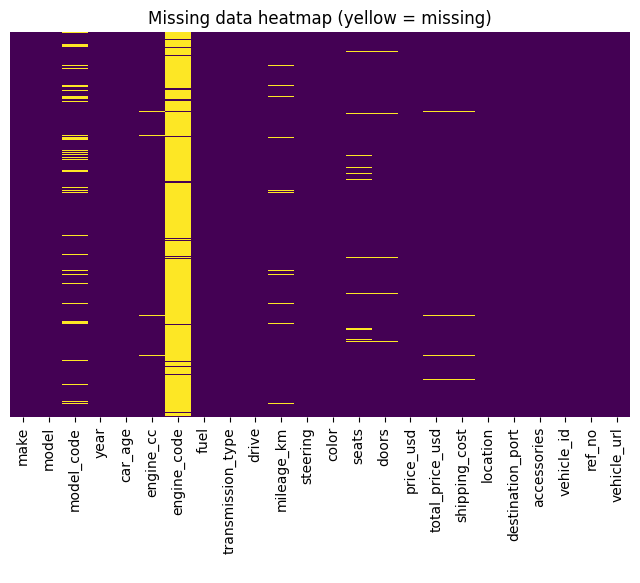

In [6]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [7]:
# 4. Target Distribution
TARGET = "price_usd"
print("Target Distribution")
print(df[TARGET].describe())

Target Distribution
count    24,744.00
mean     17,462.56
std      14,119.24
min       1,330.00
25%       9,030.00
50%      13,640.00
75%      21,460.00
max     220,870.00
Name: price_usd, dtype: float64


In [8]:
# Clip extreme outliers
q_low = df["price_usd"].quantile(0.01)
q_high = df["price_usd"].quantile(0.99)

df = df[(df["price_usd"] >= q_low) & (df["price_usd"] <= q_high)]

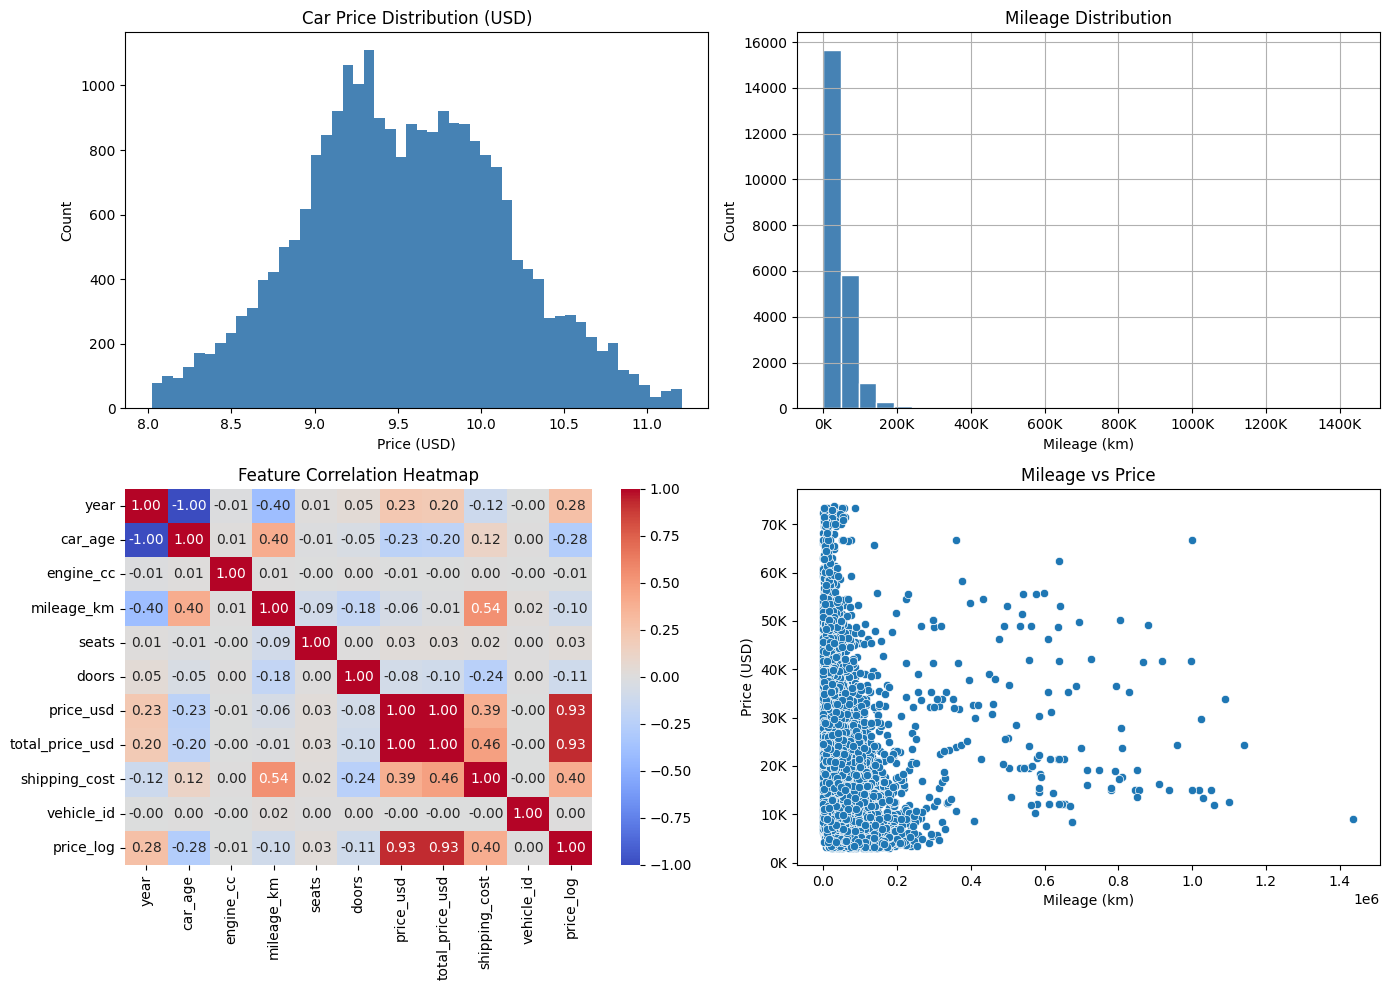

In [9]:
# Visualization

# log transform target
df['price_log'] = np.log1p(df[TARGET])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution (Price)

df["price_log"].dropna().plot(kind="hist", bins=50, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Car Price Distribution (USD)")
axes[0, 0].set_xlabel("Price (USD)")
axes[0, 0].set_ylabel("Count")

# # format in millions/thousands
# axes[0, 0].xaxis.set_major_formatter(
#     mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
# )

# Mileage distribution
df["mileage_km"].dropna().hist(
    ax=axes[0, 1],
    bins=30,
    color="steelblue",
    edgecolor="white"
)

axes[0, 1].set_title("Mileage Distribution")
axes[0, 1].set_xlabel("Mileage (km)")
axes[0, 1].set_ylabel("Count")

# optional formatting (convert to thousands)
axes[0, 1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)


# Correlation heatmap (numeric only)
num_cols = df.select_dtypes(include=np.number).columns

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Feature Correlation Heatmap")

# Mileage vs Price 
sns.scatterplot(
    x=df["mileage_km"],
    y=df[TARGET],
    ax=axes[1, 1]
)

axes[1, 1].set_title("Mileage vs Price")
axes[1, 1].set_xlabel("Mileage (km)")
axes[1, 1].set_ylabel("Price (USD)")

axes[1, 1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

<Axes: xlabel='price_usd'>

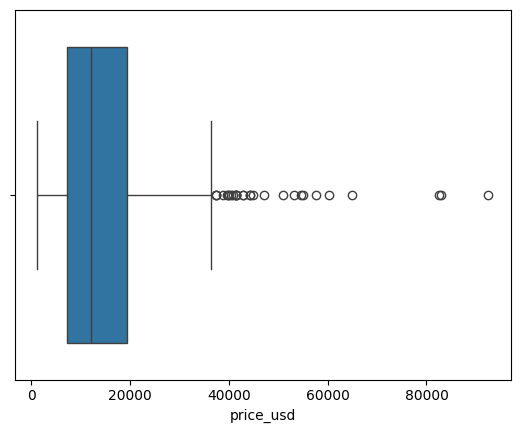

In [18]:
# target 
sns.boxplot(x=df["price_usd"])

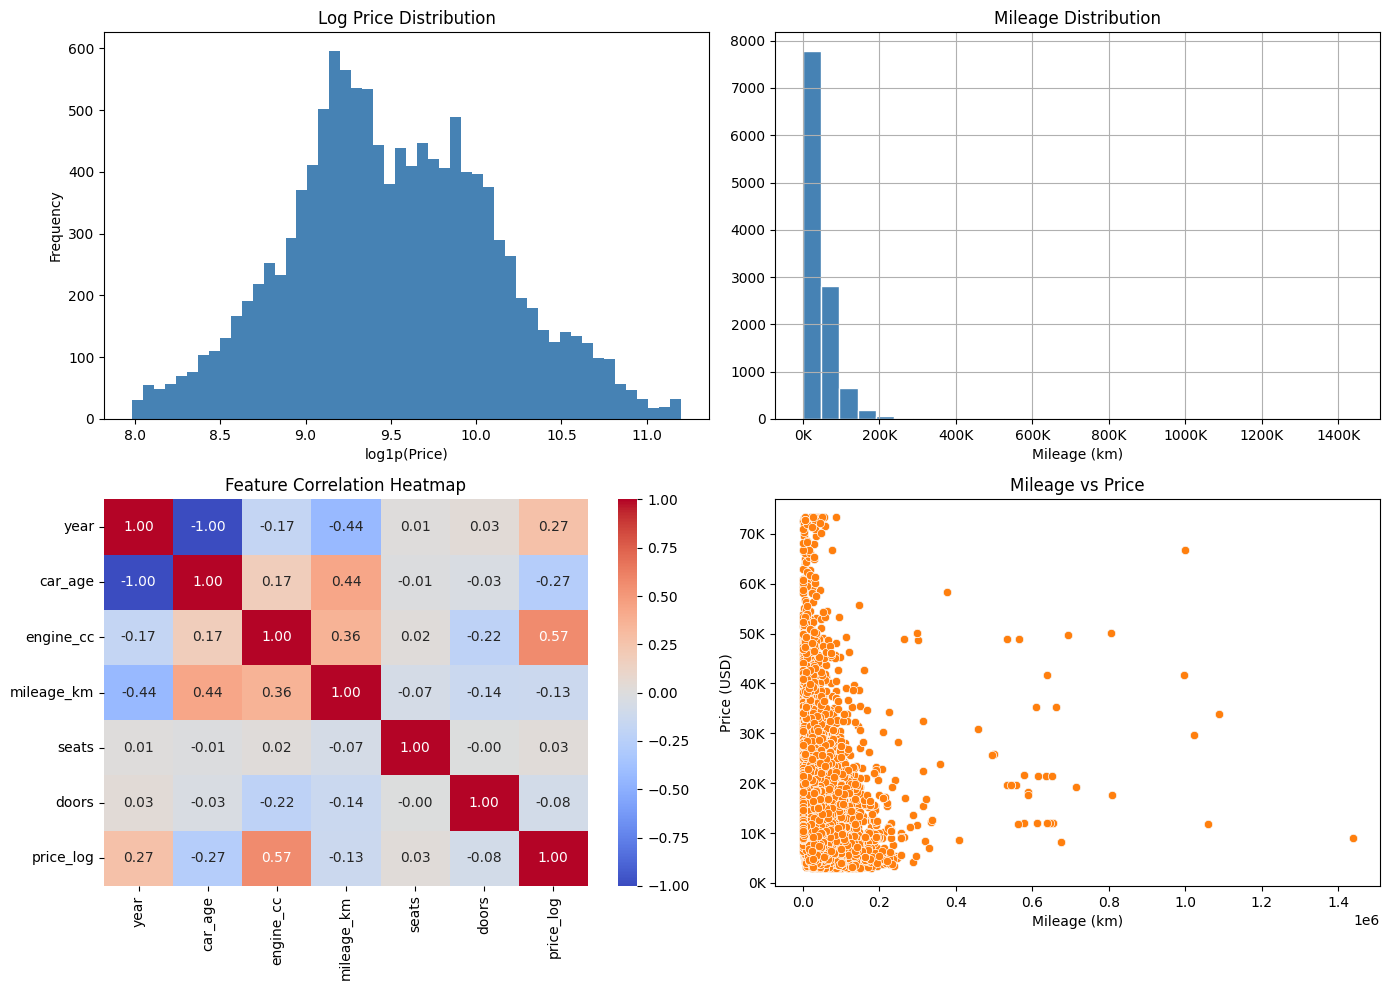

In [30]:
# log target (DO NOT overwrite original)
df["price_log"] = np.log1p(df["price_usd"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target distribution
df["price_log"].dropna().plot(kind="hist", bins=50, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Log Price Distribution")
axes[0, 0].set_xlabel("log1p(Price)")

# 2. Mileage distribution
df["mileage_km"] = pd.to_numeric(df["mileage_km"], errors="coerce")

df["mileage_km"].dropna().hist(
    ax=axes[0, 1],
    bins=30,
    color="steelblue",
    edgecolor="white"
)

axes[0, 1].set_title("Mileage Distribution")
axes[0, 1].set_xlabel("Mileage (km)")
axes[0, 1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

# 3. Correlation heatmap (clean numeric subset)
num_cols = ["year", "car_age", "engine_cc", "mileage_km", "seats", "doors", "price_log"]

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Feature Correlation Heatmap")

# 4. Mileage vs Price
sns.scatterplot(
    x=df["mileage_km"],
    y=df[TARGET],
    ax=axes[1, 1]
)

# axes[1, 1].set_title("Mileage vs Log Price")
# axes[1, 1].set_xlabel("Mileage (km)")
# Mileage vs Price 
sns.scatterplot(
    x=df["mileage_km"],
    y=df[TARGET],
    ax=axes[1, 1]
)

axes[1, 1].set_title("Mileage vs Price")
axes[1, 1].set_xlabel("Mileage (km)")
axes[1, 1].set_ylabel("Price (USD)")

axes[1, 1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)
plt.tight_layout()
plt.show()

## EDA Findings 
1. How many rows and columns?
   |rows | column |
   |---- | ----- |
   |500 | 8 |

2. Which columns have missing data and how much?

     |      | count | percentage |
     |---- | -------  | ----- |
    | grade    |     336    |    67.2 |
    | mileage_km |     1     |    0.2 | 
    | price_usd   |    1     |    0.2 |
   
3. Is the target class balanced or imbalanced?
    - The target variable (price_usd) show a strongly right-skewed distrbition.
    - The target variable (price_usd) ranges from `~$4,900` – `~$130,000`
    - Mean price - `$26,500`
    - Median price - `$23,500`
4. Which features appear most correlate with the target?
    - `engine_cc` → strong positive correlation
    - `mileage_km` → negative correlation
    - `year` → positive correlation (newer = more expensive)
5. Are there any obvious outliers to address?
    - Extremely expensive cars (e.g. AMG, Alphard)
    - Very low mileage (0–100 km “new imports”)
    - Very high mileage (>150,000 km)
